# MCMC on the HP Lattice Model: Folding Funnels from Designed Sequences

:::{admonition} **What you will learn**

- The **HP lattice model** (Lau & Dill, 1989) — the simplest caricature of a protein that still has a folding problem worth solving.
- How to run **Metropolis MCMC with pivot moves** on a self-avoiding walk to sample chain conformations.
- The **folding funnel** picture of Bryngelson, Onuchic, and Wolynes: minimally frustrated sequences have a large energy gap between the native state and the sea of misfolded states.
- How Shakhnovich's **sequence design** produces such minimally frustrated sequences — and why a random sequence looks completely different.

:::

## Why the HP model?

A protein is a heteropolymer: each residue is one of 20 amino acids, and the ones that fold reliably form a compact globule with hydrophobic residues buried in the core. Lau and Dill pointed out that you can strip this down to a **two-letter alphabet**, **H** (hydrophobic) and **P** (polar), on a **2D square lattice**, and still reproduce the essential physics of cooperative folding:

$$ E(\mathrm{conf}) \;=\; -\varepsilon \; n_{HH}(\mathrm{conf}), $$

where $n_{HH}$ is the number of **non-sequential** H–H contacts — pairs of H monomers that are adjacent on the lattice but not adjacent along the chain. This single energy term rewards compact conformations that bury hydrophobic residues.

The model is cheap enough to enumerate completely for short chains but rich enough that its statistical mechanics supports both **designed** sequences with a sharp folding transition and **random** sequences that glass over into a frustrated landscape. That is exactly the contrast we want to explore today.

**References for the ideas below:**

- K. F. Lau and K. A. Dill, *A lattice statistical mechanics model of the conformational and sequence spaces of proteins*, Macromolecules **22**, 3986 (1989). [doi:10.1021/ma00200a030](https://doi.org/10.1021/ma00200a030)
- E. I. Shakhnovich and A. M. Gutin, *Engineering of stable and fast-folding sequences of model proteins*, PNAS **90**, 7195 (1993). [doi:10.1073/pnas.90.15.7195](https://doi.org/10.1073/pnas.90.15.7195)
- J. D. Bryngelson, J. N. Onuchic, N. D. Socci, P. G. Wolynes, *Funnels, pathways, and the energy landscape of protein folding: a synthesis*, Proteins **21**, 167 (1995). [doi:10.1002/prot.340210302](https://doi.org/10.1002/prot.340210302)
- J. N. Onuchic, Z. Luthey-Schulten, P. G. Wolynes, *Theory of protein folding: the energy landscape perspective*, Annu. Rev. Phys. Chem. **48**, 545 (1997). [doi:10.1146/annurev.physchem.48.1.545](https://doi.org/10.1146/annurev.physchem.48.1.545)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

rng = np.random.default_rng(7)

## Geometry: self-avoiding walks on the square lattice

A chain of $n$ monomers is a list of lattice coordinates $(x_i, y_i)$ such that consecutive positions are lattice neighbors and no position repeats. The energy only counts **topological** H–H contacts: pairs $(i, j)$ with $|i - j| \ge 2$ that sit at unit distance on the lattice.

In [13]:
DIRS = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]], dtype=int)

# All 7 non-identity symmetries of the square lattice: 3 rotations + 4 reflections
ROTATIONS = np.array([
    [[ 0, -1], [ 1,  0]],   # +90
    [[ 0,  1], [-1,  0]],   # -90
    [[-1,  0], [ 0, -1]],   # 180
    [[ 1,  0], [ 0, -1]],   # mirror x
    [[-1,  0], [ 0,  1]],   # mirror y
    [[ 0,  1], [ 1,  0]],   # mirror y=x
    [[ 0, -1], [-1,  0]],   # mirror y=-x
], dtype=int)

def seq_to_array(s):
    '''Convert an HP string like "HPHPPH..." to a {0,1} array with H=1.'''
    return np.array([1 if c == 'H' else 0 for c in s], dtype=np.int8)

def linear_chain(n):
    '''Start the MCMC from a straight chain along the x-axis.'''
    coords = np.zeros((n, 2), dtype=int)
    coords[:, 0] = np.arange(n)
    return coords

def contacts(coords, seq):
    '''Set of non-sequential H-H contacts (as sorted tuples).'''
    pos = {(int(c[0]), int(c[1])): i for i, c in enumerate(coords)}
    out = set()
    for i, c in enumerate(coords):
        if seq[i] == 0:
            continue
        for d in DIRS:
            j = pos.get((int(c[0] + d[0]), int(c[1] + d[1])))
            if j is not None and j > i + 1 and seq[j] == 1:
                out.add((i, j))
    return out

def energy(coords, seq):
    return -len(contacts(coords, seq))

## Monte Carlo moves: the pivot algorithm

For self-avoiding walks the **pivot move** is essentially perfect. Pick a pivot index $k$, apply a random lattice symmetry $R$ (one of the 7 non-trivial rotations/reflections) to the tail $\{k+1, \dots, n-1\}$ around the pivot, and accept the move only if the resulting chain is still self-avoiding. Pivot moves are non-local: a single accepted pivot can fold the chain by 90°.

The Metropolis acceptance criterion applies the usual Boltzmann factor on top of the self-avoidance constraint.

In [14]:
def pivot_trial(coords, rng):
    '''Return a proposed configuration (or None if it is not a SAW).'''
    n = len(coords)
    k = int(rng.integers(1, n - 1))
    R = ROTATIONS[int(rng.integers(len(ROTATIONS)))]
    trial = coords.copy()
    rel = coords[k + 1:] - coords[k]
    trial[k + 1:] = coords[k] + rel @ R.T
    seen = set()
    for c in trial:
        t = (int(c[0]), int(c[1]))
        if t in seen:
            return None
        seen.add(t)
    return trial

def metropolis_hp(seq, coords, T, n_steps, rng, record_every=1):
    '''Pivot-move Metropolis MCMC for the HP model.

    Returns the final coords, the best-seen coords, the best-seen energy,
    an array of energies along the run, and a list of sampled coords.'''
    E = energy(coords, seq)
    best_c, best_E = coords.copy(), E
    Es = np.empty(n_steps)
    samples = []
    for s in range(n_steps):
        trial = pivot_trial(coords, rng)
        if trial is not None:
            Et = energy(trial, seq)
            if Et <= E or rng.random() < np.exp(-(Et - E) / T):
                coords = trial
                E = Et
                if E < best_E:
                    best_E = E
                    best_c = coords.copy()
        Es[s] = E
        if s % record_every == 0:
            samples.append(coords.copy())
    return coords, best_c, best_E, Es, samples

## Visualizing a chain

A helper to draw the chain on the lattice with H (red) and P (blue) beads, the backbone as a line, and the current H–H contacts as dotted links.

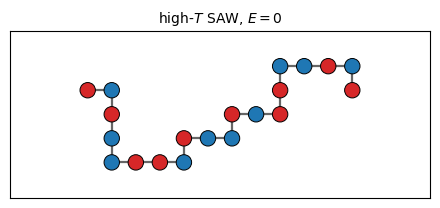

In [15]:
def draw_chain(ax, coords, seq, title=''):
    xs, ys = coords[:, 0], coords[:, 1]
    ax.plot(xs, ys, '-', color='0.4', lw=1.6, zorder=1)
    for i, (x, y) in enumerate(coords):
        c = '#d62728' if seq[i] == 1 else '#1f77b4'
        ax.add_patch(Circle((x, y), 0.32, color=c, zorder=3, ec='k', lw=0.7))
    for i, j in contacts(coords, seq):
        ax.plot([coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                ls=':', color='k', lw=1.1, zorder=2)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    ax.margins(0.25)

# Sanity check: a random pivot walk at high T should look like a floppy SAW
seq_demo = seq_to_array("HPHPPHHPHPPHPHHPPHPH")
coords_demo = linear_chain(len(seq_demo))
coords_demo, _, _, _, _ = metropolis_hp(seq_demo, coords_demo, T=5.0, n_steps=500, rng=rng)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
draw_chain(ax, coords_demo, seq_demo, title=f'high-$T$ SAW, $E = {energy(coords_demo, seq_demo)}$')
plt.tight_layout()

## From Ising spins to HP chains: watching the sampler

Before we attack the full folding problem, it is worth building intuition for what a Metropolis chain actually *does* on a self-avoiding walk. The picture is completely analogous to the 2D Ising model you just studied:

| Ising | HP |
|---|---|
| configuration = $\{s_{ij}\}$ on a square lattice | configuration = self-avoiding walk on a square lattice |
| local move: flip a single spin | non-local move: pivot a whole tail of the chain |
| energy = $-J \sum_{\langle ij \rangle} s_i s_j$ | energy = $-\varepsilon \cdot n_{HH}$ |
| Metropolis acceptance $\min(1, e^{-\beta \Delta E})$ | same |

The animation below shows a short Metropolis run on the Lau–Dill 20-mer at $T = 0.8$, starting from a straight chain. Watch two things happen simultaneously: on the left the chain buckles and compacts as hydrophobic monomers come together, and on the right the running energy drifts downward. In 300 pivot attempts the chain finds a configuration with $E \approx -4$ — nowhere near the native at $E^* = -9$. That is exactly why we will need simulated annealing in the next section.

In [16]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Short Metropolis run at T = 0.8 starting from a straight chain.
# We record the configuration and running energy at every accepted step
# so the animation tracks the sampler move by move.
rng_anim = np.random.default_rng(3)
seq_anim = seq_to_array("HPHPPHHPHPPHPHHPPHPH")
coords_anim = linear_chain(len(seq_anim))
T_anim = 0.8

traj = [coords_anim.copy()]
E_list = [energy(coords_anim, seq_anim)]
for _ in range(300):
    trial = pivot_trial(coords_anim, rng_anim)
    if trial is not None:
        Et = energy(trial, seq_anim)
        Ec = E_list[-1]
        if Et <= Ec or rng_anim.random() < np.exp(-(Et - Ec) / T_anim):
            coords_anim = trial
    traj.append(coords_anim.copy())
    E_list.append(energy(coords_anim, seq_anim))

# Downsample to ~60 frames so the animation is smooth but the file stays small
stride = max(1, len(traj) // 60)
frames_idx = list(range(0, len(traj), stride))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2),
                         gridspec_kw={'width_ratios': [1, 1.4]})
E_min = min(E_list) - 0.5
E_max = max(E_list) + 0.5

def animate(k):
    step = frames_idx[k]
    axes[0].clear()
    draw_chain(axes[0], traj[step], seq_anim,
               title=f'step {step},  $E = {E_list[step]}$')
    axes[1].clear()
    axes[1].plot(E_list[:step + 1], color='crimson', lw=1.3)
    axes[1].scatter([step], [E_list[step]], color='crimson', s=40, zorder=3)
    axes[1].set_xlim(0, len(traj))
    axes[1].set_ylim(E_min, E_max)
    axes[1].set_xlabel('MCMC step')
    axes[1].set_ylabel('$E$')
    axes[1].set_title(f'running energy at $T = {T_anim}$')
    axes[1].grid(True, ls=':', alpha=0.5)

ani = FuncAnimation(fig, animate, frames=len(frames_idx), interval=120, blit=False)
plt.close()
HTML(ani.to_jshtml())

## A designed sequence: the Lau–Dill 20-mer

The 20-mer `HPHPPHHPHPPHPHHPPHPH` is the standard benchmark introduced by Lau and Dill. Its native energy on the 2D square lattice is $E^* = -9$, and the native conformation is unique up to lattice symmetry — a hallmark of a **designed** sequence in the sense of Shakhnovich & Gutin.

We find the native by slowly annealing from high temperature. At each temperature we run a batch of pivot-Metropolis sweeps; we keep track of the lowest energy ever seen.

In [ ]:
def anneal(seq, T_schedule, n_per_T, rng, coords_init=None):
    coords = linear_chain(len(seq)) if coords_init is None else coords_init.copy()
    best_c, best_E = coords.copy(), energy(coords, seq)
    E_trace = []
    for T in T_schedule:
        coords, bc, bE, Es, _ = metropolis_hp(seq, coords, T, n_per_T, rng)
        if bE < best_E:
            best_E, best_c = bE, bc
        E_trace.append(Es)
    return best_c, best_E, np.concatenate(E_trace)

designed_seq = seq_to_array("HPHPPHHPHPPHPHHPPHPH")
T_sched = np.geomspace(3.0, 0.3, 20)

native_d, E_native_d, trace_d = anneal(designed_seq, T_sched, n_per_T=2000, rng=rng)
print(f'Designed sequence native energy found: E* = {E_native_d}')

In [ ]:
# Draw native and energy trace together
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2),
                       gridspec_kw={'width_ratios': [1, 1.6]})
draw_chain(ax[0], native_d, designed_seq,
           title=f'Designed native: $E^* = {E_native_d}$')

ax[1].plot(trace_d, lw=0.5, color='steelblue')
ax[1].axhline(E_native_d, color='crimson', ls='--', lw=1,
              label=f'$E^* = {E_native_d}$')
ax[1].set_xlabel('MCMC step')
ax[1].set_ylabel('$E$')
ax[1].set_title('Simulated-annealing energy trace (designed sequence)')
ax[1].legend()
ax[1].grid(True, ls=':', alpha=0.5)
plt.tight_layout()

## The folding funnel: $E$ vs $Q$

A single number is not enough to see the funnel — we need a **reaction coordinate** that tells us how close a configuration is to the native. The standard choice is the **fraction of native contacts**

$$ Q(\mathrm{conf}) \;=\; \frac{|\,\mathcal{C}(\mathrm{conf}) \cap \mathcal{C}^*\,|}{|\,\mathcal{C}^*\,|}, $$

where $\mathcal{C}^*$ is the set of H–H contacts in the native state and $\mathcal{C}(\mathrm{conf})$ is the set in the current conformation. $Q = 0$ is completely misfolded; $Q = 1$ is native.

The **folding funnel hypothesis** of Bryngelson, Onuchic, and Wolynes is a statement about the joint distribution of $E$ and $Q$: for a good (designed, minimally frustrated) sequence, $E$ decreases monotonically as $Q$ increases, and the native has a large gap below the bulk of misfolded states. That gap is what makes folding reproducible — it is the statistical-mechanical signature of Shakhnovich's design criterion.

In [ ]:
def make_Q_fn(native_coords, seq):
    C_star = contacts(native_coords, seq)
    n_star = max(len(C_star), 1)
    def Q(coords):
        return len(C_star & contacts(coords, seq)) / n_star
    return Q

def sample_EQ(seq, native, T_list, n_per_T, rng, record_every=10):
    '''At a range of temperatures, collect (E, Q) pairs along the run.'''
    Q_fn = make_Q_fn(native, seq)
    coords = linear_chain(len(seq))
    E_all, Q_all = [], []
    for T in T_list:
        _, _, _, Es, samples = metropolis_hp(
            seq, coords, T, n_per_T, rng, record_every=record_every)
        coords = samples[-1]
        for c in samples:
            E_all.append(energy(c, seq))
            Q_all.append(Q_fn(c))
    return np.array(E_all), np.array(Q_all)

T_funnel = np.geomspace(2.5, 0.4, 10)
E_d, Q_d = sample_EQ(designed_seq, native_d, T_funnel,
                     n_per_T=1500, rng=rng, record_every=20)

## A random sequence for comparison

Shakhnovich's point is that **most** sequences do not fold nicely. They are frustrated: many conformations with different contact patterns have comparable energies, so there is no clean path to a unique ground state. To see this, we generate a random 20-mer with the same overall composition and repeat the analysis.

In [ ]:
random_seq = np.array([1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0], dtype=np.int8)
print('Designed H fraction:', designed_seq.mean(), ' random H fraction:', random_seq.mean())

native_r, E_native_r, trace_r = anneal(random_seq, T_sched, n_per_T=2000, rng=rng)
print(f'Random sequence best energy found: E = {E_native_r}')

E_r, Q_r = sample_EQ(random_seq, native_r, T_funnel,
                     n_per_T=1500, rng=rng, record_every=20)

In [ ]:
# Side-by-side: funnel for designed vs random sequence
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, (E, Q, lbl, E_nat) in zip(axes, [
        (E_d, Q_d, 'Designed: Lau-Dill 20-mer', E_native_d),
        (E_r, Q_r, 'Random 20-mer', E_native_r)]):
    h = ax.hexbin(Q, E, gridsize=25, cmap='viridis', mincnt=1, bins='log')
    ax.axhline(E_nat, color='crimson', ls='--', lw=1,
               label=f'$E^* = {E_nat}$')
    ax.set_xlabel('$Q$ = fraction of native contacts')
    ax.set_title(lbl)
    ax.legend(loc='upper right')
    ax.grid(True, ls=':', alpha=0.4)

axes[0].set_ylabel('$E$')
fig.colorbar(h, ax=axes, label='log density of samples')
# fig.suptitle('Folding funnels: designed sequence has a clean slope down to a deep native', y=1.02)
plt.show()

The scatter for the **designed** sequence has the shape of a funnel — the typical energy decreases smoothly as $Q \to 1$, and the native sits visibly below the bulk. The **random** sequence instead shows a cloud at mid-$Q$ with a much smaller (or absent) gap between its apparent ground state and the misfolded soup. This is frustration in action: many conformations of the random chain have nearly degenerate energies, so MCMC wanders among them instead of converging.

## The energy gap, shifted and at low temperature

A plain histogram of all sampled energies mixes high-$T$ disorder with low-$T$ near-native states and blurs out the gap we care about. Two fixes make the gap legible:

1. **Look only at the low-$T$ tail of the anneal** — the last few temperatures of the cooling schedule are already below the folding transition of the designed sequence, so the distribution there is dominated by near-native states.
2. **Shift each sequence's histogram by its own native energy**, plotting $\delta E = E - E^*$. That way the native sits at $\delta E = 0$ for both sequences and we can compare the *shape* of the distribution above it.

The difference becomes stark: the designed sequence is sharply peaked at $\delta E = 0$ with almost all weight in $\delta E \in \{0, 1\}$ — classic two-state folding. The random sequence is broad, peaked at $\delta E \approx 3$, with significant weight out to $\delta E \sim 6$ — a frustrated soup of misfolded structures.

In [ ]:
# Use the LAST few temperatures of the annealing schedule (i.e. the low-T tail)
# where the chain is already inside its native basin. Shift by the native energy.
n_low = 8000   # last 8000 MCMC steps of each anneal trace (4 coldest T values)
low_d = trace_d[-n_low:] - E_native_d
low_r = trace_r[-n_low:] - E_native_r

bins = np.arange(-0.5, 9.5, 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)

ax[0].hist(low_d, bins=bins, color='steelblue', alpha=0.85,
           edgecolor='white', density=True)
ax[0].set_title(f'Designed 20-mer  ($E^* = {E_native_d}$)')
ax[0].set_xlabel(r'$\delta E = E - E^*$')
ax[0].set_ylabel('probability')
ax[0].grid(True, ls=':', alpha=0.5)

ax[1].hist(low_r, bins=bins, color='darkorange', alpha=0.85,
           edgecolor='white', density=True)
ax[1].set_title(f'Random 20-mer  ($E^* = {E_native_r}$)')
ax[1].set_xlabel(r'$\delta E = E - E^*$')
ax[1].grid(True, ls=':', alpha=0.5)

# Print a quick numerical summary
p0_d = (low_d == 0).mean();  p0_r = (low_r == 0).mean()
mean_d = low_d.mean();       mean_r = low_r.mean()
print(f'Designed: P(native) = {p0_d:.2f},  <delta E> = {mean_d:.2f}')
print(f'Random:   P(native) = {p0_r:.2f},  <delta E> = {mean_r:.2f}')
fig.suptitle('Low-$T$ energy distribution, shifted by the native energy',
             y=1.02, fontsize=11)
plt.tight_layout()

The designed sequence piles up at $\delta E = 0$ (native) and $\delta E = 1$ — a *two-state* distribution with essentially no population at intermediate or higher energies. The random sequence spreads its weight all the way out to $\delta E \sim 5\text{–}6$, peaking in the middle rather than at its ground state. This is what frustration looks like in the density of states: many conformations with comparable energies, none of them preferentially stabilized.

Shakhnovich & Gutin's 1993 design procedure explicitly maximizes the native's energetic separation from the misfolded soup, and the Bryngelson–Onuchic–Wolynes funnel theory connects this gap to the ratio $T_f / T_g$ — the folding temperature over the glass temperature — which must be $\gg 1$ for a protein to fold reproducibly.

## The native state, drawn

Finally, a picture of the designed native so you can count contacts by hand and convince yourself the MCMC did its job.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
draw_chain(axes[0], native_d, designed_seq,
           title=f'Designed native  ($E^* = {E_native_d}$)')
draw_chain(axes[1], native_r, random_seq,
           title=f'Random best-found  ($E = {E_native_r}$)')
plt.tight_layout()

## Problems

1. **Heat capacity and folding transition.** Run parallel-tempered MCMC on the designed 20-mer across $T \in [0.3, 3.0]$ and compute $C_V(T) = \mathrm{Var}(E)/T^2$. The designed sequence should show a sharp peak at the folding temperature $T_f$; the random one should not. Plot both on the same axes.

2. **Designing your own sequence.** Pick a short target conformation (e.g. a $4 \times 4$ compact square) and use the Shakhnovich–Gutin idea: at fixed conformation, do MCMC **on the sequence** (swap H/P labels) minimizing the energy gap to alternative structures. Check that the resulting sequence folds to your target under structural MCMC.

3. **Funnel slope.** Bin the $(Q, E)$ samples of the designed sequence and fit $\langle E \rangle(Q)$ to a straight line. The slope is one operational definition of the folding funnel's steepness. Compare its magnitude to the slope you get for the random sequence.

4. **Replica exchange vs annealing.** The annealing schedule used here is fragile: if we cool too quickly we sometimes miss the true native. Replace `anneal` with a replica-exchange driver over the same temperature ladder and measure how often the $E = -9$ ground state is found in 10 independent runs with each method.

## Takeaways

- The HP model reduces protein folding to a tractable statistical-mechanics problem while preserving the essential ingredient: a heteropolymer on a lattice with one short-ranged attractive interaction.
- Pivot-move Metropolis MCMC is the simplest effective sampler for self-avoiding walks and suffices to find the native state of short designed sequences.
- **Minimal frustration** (Bryngelson–Onuchic–Wolynes) is not a vague metaphor — it is directly visible as a clean funnel in the $(Q, E)$ scatter plot and as a gap in the energy histogram.
- **Design matters** (Shakhnovich–Gutin): almost all random sequences are frustrated. Evolution has selected the tiny subset of sequences that fold.